<a href="https://colab.research.google.com/github/HAROUNTOUM/notebooks/blob/main/tp5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Total files: 2617

Class distribution:
class
0    353
1    382
2    379
3    387
4    377
5    375
6    364
Name: count, dtype: int64


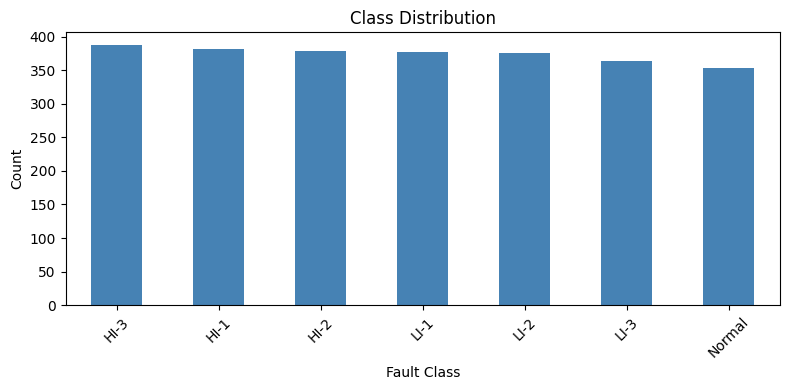


Sample file: 1_c0080c30c000.csv  →  shape: (100000, 5)


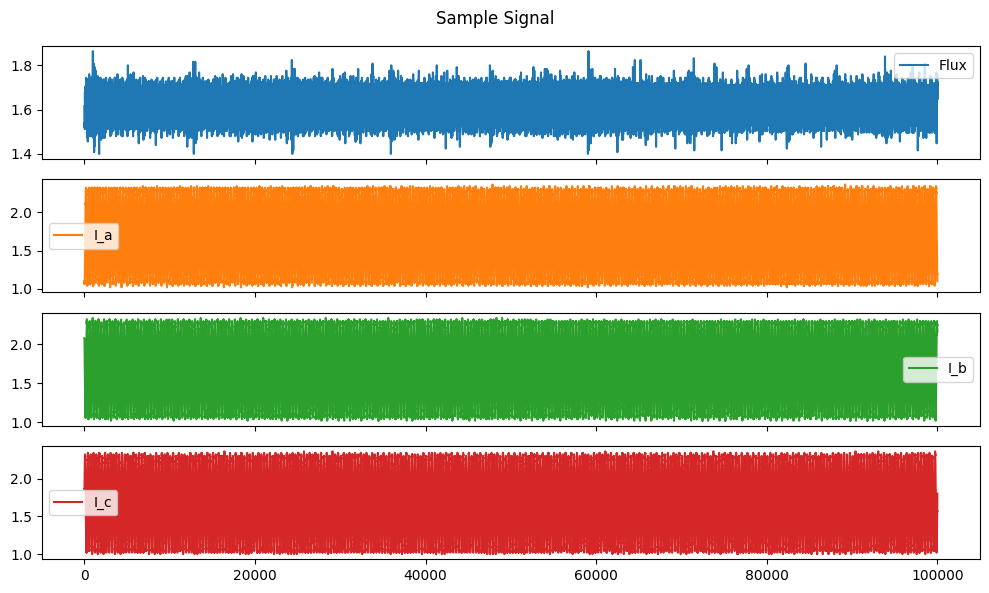


Feature vector size: 36


Extracting features:   1%|          | 26/2617 [00:03<04:25,  9.76it/s]/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1344: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean
Extracting features:   2%|▏         | 56/2617 [00:06<04:25,  9.64it/s]/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1344: RuntimeWarning: invalid value encou


X shape: (2617, 36)  |  y shape: (2617,)


ValueError: Input X contains infinity or a value too large for dtype('float64').

In [4]:
import os
import re
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ── 1. Load file list ─────────────────────────────────────────────────────────
data_dir = Path("data/Renomeado/")
all_files = [f for f in data_dir.glob("*.csv") if not f.name.startswith("._")]
print(f"Total files: {len(all_files)}")

# ── 2. Parse filenames ────────────────────────────────────────────────────────
def parse_filename(fname):
    name = Path(fname).stem
    match = re.match(r'^(\d+)_c(\d+)c(\d+)c(\d+)$', name)
    if match:
        cls, idx, freq, load = match.groups()
        return int(cls), int(idx), int(freq), int(load)
    return None, None, None, None

rows = []
for f in all_files:
    cls, idx, freq, load = parse_filename(f.name)
    if cls is not None:
        rows.append({"filepath": str(f), "class": cls,
                     "sample_idx": idx, "freq_hz": freq, "load_pct": load})

meta_df = pd.DataFrame(rows)
label_names = {0:"Normal", 1:"HI-1", 2:"HI-2", 3:"HI-3", 4:"LI-1", 5:"LI-2", 6:"LI-3"}
meta_df["label"] = meta_df["class"].map(label_names)
print("\nClass distribution:")
print(meta_df["class"].value_counts().sort_index())

# ── 3. Class distribution plot ────────────────────────────────────────────────
meta_df["label"].value_counts().plot(kind="bar", figsize=(8, 4), color="steelblue")
plt.title("Class Distribution")
plt.xlabel("Fault Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ── 4. CSV loader (skips Tektronix oscilloscope header) ───────────────────────
def load_csv(filepath):
    with open(filepath, "r") as f:
        lines = f.readlines()
    skip = 0
    for i, line in enumerate(lines):
        if line.strip().startswith("TIME"):
            skip = i + 1
            break
    df = pd.read_csv(filepath, header=None, skiprows=skip,
                     names=["Time", "Flux", "I_a", "I_b", "I_c"])
    df = df.apply(pd.to_numeric, errors="coerce").dropna()
    return df

# ── 5. Plot a sample signal ───────────────────────────────────────────────────
sample_file = meta_df.iloc[0]["filepath"]
df_sample = load_csv(sample_file)
print(f"\nSample file: {Path(sample_file).name}  →  shape: {df_sample.shape}")
df_sample[["Flux", "I_a", "I_b", "I_c"]].plot(
    subplots=True, figsize=(10, 6), title="Sample Signal")
plt.tight_layout()
plt.show()

# ── 6. Feature extraction (9 stats × 4 channels = 36 features) ───────────────
def extract_features(filepath):
    df = load_csv(filepath)
    features = []
    for col in ["Flux", "I_a", "I_b", "I_c"]:
        s = df[col].values
        if s.size == 0:
            features += [np.nan] * 9
        else:
            features += [
                np.mean(s),
                np.std(s),
                np.max(s),
                np.min(s),
                np.max(s) - np.min(s),
                np.sqrt(np.mean(s**2)),
                np.mean(np.abs(s)),
                pd.Series(s).skew(),
                pd.Series(s).kurt(),
            ]
    return features

feature_names = [f"{col}_{stat}"
                 for col in ["Flux", "I_a", "I_b", "I_c"]
                 for stat in ["mean","std","max","min","p2p","rms","mav","skew","kurt"]]
print(f"\nFeature vector size: {len(feature_names)}")

# ── 7. Build feature matrix ───────────────────────────────────────────────────
X, y = [], []
for _, row in tqdm(meta_df.iterrows(), total=len(meta_df), desc="Extracting features"):
    X.append(extract_features(row["filepath"]))
    y.append(row["class"])

X = np.array(X)
y = np.array(y)
print(f"\nX shape: {X.shape}  |  y shape: {y.shape}")

# ── 8. Train / test split + scaling ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

# ── 9. Random Forest classifier ───────────────────────────────────────────────
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                             target_names=list(label_names.values())))

# ── 10. Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names.values(),
            yticklabels=label_names.values())
plt.title("Confusion Matrix — Random Forest")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

Rows with NaN/Inf removed: 15 / 2617
Clean X shape: (2602, 36)  |  y shape: (2602,)
Train: (2081, 36)  |  Test: (521, 36)

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        70
        HI-1       0.99      0.96      0.97        77
        HI-2       1.00      0.97      0.99        76
        HI-3       0.99      1.00      0.99        77
        LI-1       0.96      0.99      0.97        75
        LI-2       0.99      0.99      0.99        73
        LI-3       0.99      1.00      0.99        73

    accuracy                           0.99       521
   macro avg       0.99      0.99      0.99       521
weighted avg       0.99      0.99      0.99       521



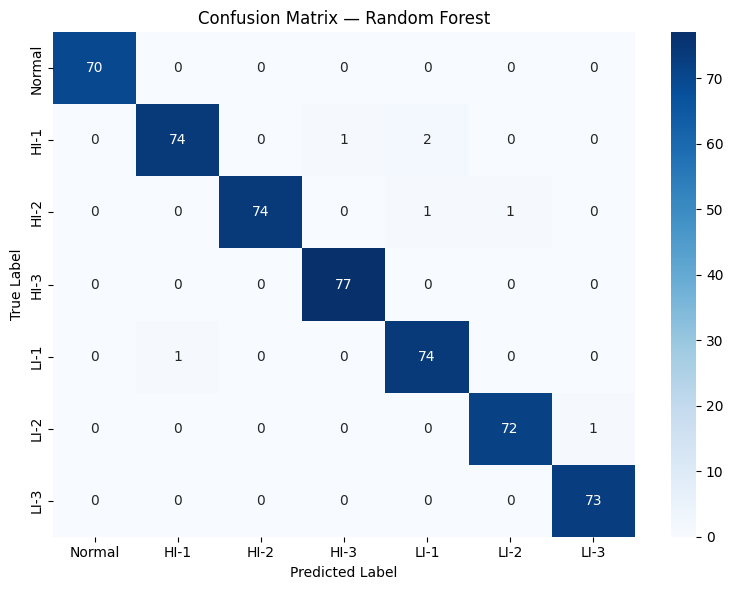

In [5]:
X = pd.DataFrame(X, columns=feature_names)
X.replace([np.inf, -np.inf], np.nan, inplace=True)

bad_mask = X.isnull().any(axis=1)
print(f"Rows with NaN/Inf removed: {bad_mask.sum()} / {len(X)}")

X = X[~bad_mask].values
y = y[~bad_mask]
print(f"Clean X shape: {X.shape}  |  y shape: {y.shape}")

# ── 9. Train / test split + scaling ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

# ── 10. Random Forest classifier ──────────────────────────────────────────────
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                             target_names=list(label_names.values())))

# ── 11. Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names.values(),
            yticklabels=label_names.values())
plt.title("Confusion Matrix — Random Forest")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [3]:
!kaggle datasets download -d rebecacunha/mit-short-circuit-flux-and-current-signals -o
!unzip -o mit-short-circuit-flux-and-current-signals.zip -d data/

Dataset URL: https://www.kaggle.com/datasets/rebecacunha/mit-short-circuit-flux-and-current-signals
License(s): CC-BY-NC-SA-4.0
  3% 57.0M/1.74G [00:02<01:07, 26.8MB/s]
User cancelled operation
Archive:  mit-short-circuit-flux-and-current-signals.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of mit-short-circuit-flux-and-current-signals.zip or
        mit-short-circuit-flux-and-current-signals.zip.zip, and cannot find mit-short-circuit-flux-and-current-signals.zip.ZIP, period.
